# Retail Sales & Velocity Analytics Deliverable
**Practical Assessment: 6-Month Snapshot Analysis**
**Dataset Source:** `Product Sales Analysis.xlsx` (8,843 product-location records)
**Deliverable Architecture:** Single Source of Truth Analytics Notebook & Interactive Dashboard Data Pipeline


## 1. Setup & Data Understanding

### Structural Data Limitations
Before ingesting and manipulating the dataset, we establish two critical structural limitations inherent to this data snapshot:
1. **No Date/Time Column (Fixed Single-Window Snapshot)**: The dataset contains no transaction timestamps or dates. It represents an aggregated 6-month snapshot. Consequently, we cannot analyze velocity decay over time, seasonal patterns, demand trends, or days-since-last-sale.
2. **No Inventory-on-Hand Column (No Stock Position)**: The dataset records historical unit sales and revenue, but does not provide beginning, ending, or current on-hand inventory levels. Therefore, we cannot calculate true sell-through rates (Units Sold / Starting Inventory), days of supply (DOI), or determine whether an item sold 0 units because of zero demand vs. an unfulfilled stockout.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 150

# Load dataset
file_path = 'Product Sales Analysis.xlsx'
df_raw = pd.read_excel(file_path)

print(f"Dataset Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns\n")
print("Columns & Data Types:")
print(df_raw.dtypes)
print("\nMissing / Null Values Count:")
print(df_raw.isnull().sum())
print("\nFirst 5 Rows Preview:")
df_raw.head()


Dataset Shape: 8,843 rows, 12 columns

Columns & Data Types:
ITEM NAME                     object
PARENT CATEGORY               object
CATEGORY                      object
LOCATION                      object
VENDOR                        object
NET SALES                    float64
GROSS SALES                  float64
ORDER TOTAL                    int64
QUANTITY SOLD                  int64
TOTAL COGS                   float64
MARGIN % FROM GROSS SALES    float64
MARGIN % FROM NET SALES      float64
dtype: object

Missing / Null Values Count:
ITEM NAME                     0
PARENT CATEGORY               0
CATEGORY                      0
LOCATION                      0
VENDOR                        0
NET SALES                     0
GROSS SALES                   0
ORDER TOTAL                   0
QUANTITY SOLD                 0
TOTAL COGS                    0
MARGIN % FROM GROSS SALES    17
MARGIN % FROM NET SALES       5
dtype: int64

First 5 Rows Preview:


,ITEM NAME,PARENT CATEGORY,CATEGORY,LOCATION,VENDOR,NET SALES,GROSS SALES,ORDER TOTAL,QUANTITY SOLD,TOTAL COGS,MARGIN % FROM GROSS SALES,MARGIN % FROM NET SALES
0,Series-A-0001,Accessories,Accessories,B,Vendor-001,39.81,40.0,1,1,0.0,NaN,1.000000
1,Series-A-0002,Accessories,Accessories,C,Vendor-001,43.33,50.0,2,2,24.0,0.520000,0.446111
2,Series-A-0003,Accessories,Accessories,C,Vendor-001,22.07,25.0,1,1,12.0,0.520000,0.456275
3,Series-A-0004,Accessories,Accessories,B,Vendor-001,32.23,80.0,1,1,80.0,0.000000,-1.482159
4,Series-A-0005,Accessories,Accessories,A,Vendor-001,7.41,8.5,2,2,2.6,0.694118,0.649123


## 2. Cleaning & Accounting Rules

### Written Rules for Data Standardization and Anomaly Handling
To ensure exact mathematical reproducibility and auditability, the following explicit rules are applied:

1. **Whitespace Normalization Rule**:
   - Categorical columns (`PARENT CATEGORY`, `CATEGORY`, `LOCATION`, `VENDOR`, `ITEM NAME`) contain trailing and leading whitespace anomalies (e.g., `'Flower '` vs `'Flower'`, `'Beverages '` vs `'Beverages'`).
   - *Rule*: Apply string trimming (`.str.strip()`) across all categorical text columns to collapse duplicate category labels into single authoritative entities.

2. **Negative Net Sales & Quantities Handling Rule**:
   - A small subset of rows exhibit negative `NET SALES` ($< 0$) and/or negative `QUANTITY SOLD` (e.g. Row 217, 7097).
   - *Interpretation*: In standard retail accounting, negative sales rows reflect processed customer refunds, item returns, or post-period accounting adjustments without corresponding positive offsetting gross sales in the window.
   - *Rule*: Retain negative rows for total financial reconciliation ($7,712,364.96 net sales audit), but classify rows with non-positive net sales or zero/negative units directly into the **Dead Stock** tier during forward replenishment and merchandising evaluations.

3. **Margin % Recalculation & Outlier Correction Rule**:
   - The raw column `MARGIN % FROM NET SALES` exhibits extreme outlier values (ranging down to -7999.00 / -799,900%) caused by near-zero net sales denominators (e.g., promotional giveaway or penny-samples where Net Sales = $0.01 while COGS = $80.00).
   - Furthermore, 5 rows have `NaN` margins due to $0.00 Net Sales.
   - *Rule*: Authoritative Margin Dollars are computed as:
     $$\text{Margin Dollars} = \text{Net Sales} - \text{Total COGS}$$
   - Authoritative Margin % is recalculated as:
     $$\text{Margin \%} = \begin{cases} \frac{\text{Net Sales} - \text{Total COGS}}{\text{Net Sales}}, & \text{if } \text{Net Sales} > 0 \\ \text{NaN}, & \text{if } \text{Net Sales} \le 0 \end{cases}$$
   - When Total COGS = 0 and Net Sales > 0, Margin % evaluates cleanly to 1.0 (100%), flagged as zero-cost inventory / data gap.


In [2]:
# Apply Cleaning Rules
df = df_raw.copy()

# 1. Trim whitespace
categorical_cols = ['PARENT CATEGORY', 'CATEGORY', 'LOCATION', 'VENDOR', 'ITEM NAME']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# 2. Compute Authoritative Margin Dollars and Recalculated Margin %
df['MARGIN_DOLLARS'] = df['NET SALES'] - df['TOTAL COGS']
df['MARGIN_PCT'] = np.where(df['NET SALES'] > 0, df['MARGIN_DOLLARS'] / df['NET SALES'], np.nan)

# Validate cleaned categorical unique counts
print(f"Authoritative Parent Categories ({df['PARENT CATEGORY'].nunique()}): {sorted(df['PARENT CATEGORY'].unique().tolist())}")
print(f"Authoritative Locations ({df['LOCATION'].nunique()}): {sorted(df['LOCATION'].unique().tolist())}")
print(f"Total Unique Vendors: {df['VENDOR'].nunique()}")
print(f"Total Unique Items: {df['ITEM NAME'].nunique()}")

# Audit anomalies
neg_sales_count = (df['NET SALES'] < 0).sum()
neg_margin_count = ((df['MARGIN_DOLLARS'] < 0) & (df['NET SALES'] > 0)).sum()
zero_cogs_count = ((df['TOTAL COGS'] == 0) & (df['NET SALES'] > 0)).sum()

print(f"\nAnomaly Verification:")
print(f" - Negative Net Sales rows: {neg_sales_count}")
print(f" - Negative Margin $ rows (Loss-makers): {neg_margin_count}")
print(f" - Zero COGS rows: {zero_cogs_count}")


Authoritative Parent Categories (11): ['Accessories', 'Beverages', 'CBD', 'Clothing Apparel', 'Concentrates', 'Edibles', 'Flower', 'Pre-Roll', 'THC Oil', 'Uncategorized', 'Vape']
Authoritative Locations (3): ['A', 'B', 'C']
Total Unique Vendors: 162
Total Unique Items: 5356

Anomaly Verification:
 - Negative Net Sales rows: 3
 - Negative Margin $ rows (Loss-makers): 170
 - Zero COGS rows: 12


## 3. Velocity & Dead-Stock Module

### Methodology & Threshold Justification
In retail merchandising, sales velocity must be evaluated **relative to the product's parent category**. For example, selling 20 units of Flower over 6 months represents a low-to-medium mover, whereas selling 20 units of high-ticket Concentrates or Accessories represents a fast-moving item.

#### Segmentation Thresholds:
1. **Dead Stock (Category Percentile $\le 0.10$ or Quantity $\le 0$ or Net Sales $\le 0$)**:
   - *Justification*: SKUs with zero/negative sales, or unit movement falling in the bottom 10th percentile of their category (selling $\le 1-2$ units across half a year). These represent stagnant, non-productive inventory tying up display space.
2. **Slow Mover ($0.10 < \text{Percentile} \le 0.30$)**:
   - *Justification*: Infrequent purchases representing sluggish velocity; candidates for SKU rationalization or promotional clearance.
3. **Medium Mover ($0.30 < \text{Percentile} \le 0.75$)**:
   - *Justification*: The consistent core assortment generating steady recurring volume.
4. **Fast Mover ($\text{Percentile} > 0.75$)**:
   - *Justification*: The top quartile velocity drivers generating the vast majority of foot traffic and unit turns; must be protected against stockouts.

The module exports `item_velocity.csv` to serve as the unified data backend for the interactive dashboard.


In [3]:
# Compute Category-Relative Percentile Rank based on QUANTITY SOLD
df['PERCENTILE'] = df.groupby('PARENT CATEGORY')['QUANTITY SOLD'].rank(pct=True, method='min')

def assign_velocity_tier(row):
    if row['QUANTITY SOLD'] <= 0 or row['NET SALES'] <= 0:
        return 'Dead Stock'
    pct = row['PERCENTILE']
    if pct <= 0.10:
        return 'Dead Stock'
    elif pct <= 0.30:
        return 'Slow Mover'
    elif pct <= 0.75:
        return 'Medium Mover'
    else:
        return 'Fast Mover'

df['TIER'] = df.apply(assign_velocity_tier, axis=1)

# Tier Summary Table
tier_summary = df.groupby('TIER').agg(
    SKU_Count=('ITEM NAME', 'count'),
    Total_Quantity=('QUANTITY SOLD', 'sum'),
    Total_Net_Sales=('NET SALES', 'sum'),
    Total_COGS=('TOTAL COGS', 'sum'),
    Total_Margin_Dollars=('MARGIN_DOLLARS', 'sum')
).reindex(['Fast Mover', 'Medium Mover', 'Slow Mover', 'Dead Stock']).reset_index()

tier_summary['SKU_Share_%'] = (tier_summary['SKU_Count'] / len(df)) * 100
tier_summary['Sales_Share_%'] = (tier_summary['Total_Net_Sales'] / df['NET SALES'].sum()) * 100
tier_summary['Avg_Margin_%'] = (tier_summary['Total_Margin_Dollars'] / tier_summary['Total_Net_Sales']) * 100

print("Velocity Tier Distribution Summary:")
display(tier_summary.style.format({
    'SKU_Count': '{:,}',
    'Total_Quantity': '{:,}',
    'Total_Net_Sales': '${:,.2f}',
    'Total_COGS': '${:,.2f}',
    'Total_Margin_Dollars': '${:,.2f}',
    'SKU_Share_%': '{:.2f}%',
    'Sales_Share_%': '{:.2f}%',
    'Avg_Margin_%': '{:.2f}%'
}))

# Export clean item_velocity.csv
output_columns = [
    'ITEM NAME', 'LOCATION', 'PARENT CATEGORY', 'CATEGORY', 'VENDOR',
    'QUANTITY SOLD', 'NET SALES', 'GROSS SALES', 'TOTAL COGS', 'MARGIN_DOLLARS',
    'MARGIN_PCT', 'PERCENTILE', 'TIER'
]

export_df = df[output_columns].rename(columns={
    'ITEM NAME': 'item_name',
    'LOCATION': 'location',
    'PARENT CATEGORY': 'parent_category',
    'CATEGORY': 'category',
    'VENDOR': 'vendor',
    'QUANTITY SOLD': 'quantity_sold',
    'NET SALES': 'net_sales',
    'GROSS SALES': 'gross_sales',
    'TOTAL COGS': 'total_cogs',
    'MARGIN_DOLLARS': 'margin_dollars',
    'MARGIN_PCT': 'margin_pct',
    'PERCENTILE': 'percentile',
    'TIER': 'tier'
})

export_df.to_csv('item_velocity.csv', index=False)
print(f"\nSuccessfully exported {len(export_df):,} rows to 'item_velocity.csv'")


Velocity Tier Distribution Summary:


,TIER,SKU_Count,Total_Quantity,Total_Net_Sales,Total_COGS,Total_Margin_Dollars,SKU_Share_%,Sales_Share_%,Avg_Margin_%
0,Fast Mover,"2,197","190,687","$4,850,580.90","$2,587,664.54","$2,262,916.36",24.84%,62.89%,46.65%
1,Medium Mover,"3,927","69,638","$2,517,960.13","$1,371,788.72","$1,146,171.41",44.41%,32.65%,45.52%
2,Slow Mover,"1,489","6,717","$267,388.63","$141,864.90","$125,523.74",16.84%,3.47%,46.94%
3,Dead Stock,"1,230","1,699","$76,435.30","$40,413.52","$36,021.78",13.91%,0.99%,47.13%



Successfully exported 8,843 rows to 'item_velocity.csv'


## 4. Q1 — Performance Patterns

### Performance Aggregations: Categories, Locations, and Vendors
We aggregate financial performance across Parent Category, Store Location, and Vendor to evaluate commercial drivers and margin health.


In [4]:
# 1. Parent Category Aggregation
cat_perf = df.groupby('PARENT CATEGORY').agg(
    Net_Sales=('NET SALES', 'sum'),
    Gross_Sales=('GROSS SALES', 'sum'),
    Total_COGS=('TOTAL COGS', 'sum'),
    Margin_Dollars=('MARGIN_DOLLARS', 'sum'),
    Quantity_Sold=('QUANTITY SOLD', 'sum'),
    Order_Total=('ORDER TOTAL', 'sum'),
    SKU_Count=('ITEM NAME', 'count')
).reset_index()
cat_perf['Margin_%'] = (cat_perf['Margin_Dollars'] / cat_perf['Net_Sales']) * 100
cat_perf['Sales_Share_%'] = (cat_perf['Net_Sales'] / df['NET SALES'].sum()) * 100
cat_perf = cat_perf.sort_values(by='Net_Sales', ascending=False)

print("Parent Category Financial Performance:")
display(cat_perf.style.format({
    'Net_Sales': '${:,.2f}',
    'Gross_Sales': '${:,.2f}',
    'Total_COGS': '${:,.2f}',
    'Margin_Dollars': '${:,.2f}',
    'Quantity_Sold': '{:,}',
    'Order_Total': '{:,}',
    'SKU_Count': '{:,}',
    'Margin_%': '{:.2f}%',
    'Sales_Share_%': '{:.2f}%'
}))

# 2. Location Aggregation
loc_perf = df.groupby('LOCATION').agg(
    Net_Sales=('NET SALES', 'sum'),
    Total_COGS=('TOTAL COGS', 'sum'),
    Margin_Dollars=('MARGIN_DOLLARS', 'sum'),
    Quantity_Sold=('QUANTITY SOLD', 'sum'),
    Order_Total=('ORDER TOTAL', 'sum'),
    SKU_Count=('ITEM NAME', 'count')
).reset_index()
loc_perf['Margin_%'] = (loc_perf['Margin_Dollars'] / loc_perf['Net_Sales']) * 100
loc_perf['Sales_Share_%'] = (loc_perf['Net_Sales'] / df['NET SALES'].sum()) * 100

print("\nLocation Performance:")
display(loc_perf.style.format({
    'Net_Sales': '${:,.2f}',
    'Total_COGS': '${:,.2f}',
    'Margin_Dollars': '${:,.2f}',
    'Quantity_Sold': '{:,}',
    'Order_Total': '{:,}',
    'SKU_Count': '{:,}',
    'Margin_%': '{:.2f}%',
    'Sales_Share_%': '{:.2f}%'
}))

# 3. Top 10 Vendors
top_vendors = df.groupby('VENDOR').agg(
    Net_Sales=('NET SALES', 'sum'),
    Margin_Dollars=('MARGIN_DOLLARS', 'sum'),
    Quantity_Sold=('QUANTITY SOLD', 'sum'),
    SKU_Count=('ITEM NAME', 'count')
).reset_index()
top_vendors['Margin_%'] = (top_vendors['Margin_Dollars'] / top_vendors['Net_Sales']) * 100
top_vendors['Sales_Share_%'] = (top_vendors['Net_Sales'] / df['NET SALES'].sum()) * 100
top_vendors = top_vendors.sort_values(by='Net_Sales', ascending=False).head(10)

print("\nTop 10 Vendors by Net Sales:")
display(top_vendors.style.format({
    'Net_Sales': '${:,.2f}',
    'Margin_Dollars': '${:,.2f}',
    'Quantity_Sold': '{:,}',
    'SKU_Count': '{:,}',
    'Margin_%': '{:.2f}%',
    'Sales_Share_%': '{:.2f}%'
}))


Parent Category Financial Performance:


,PARENT CATEGORY,Net_Sales,Gross_Sales,Total_COGS,Margin_Dollars,Quantity_Sold,Order_Total,SKU_Count,Margin_%,Sales_Share_%
6,Flower,"$3,038,151.06","$3,399,190.61","$1,675,058.59","$1,363,092.47","62,461","58,423","2,797",44.87%,39.39%
10,Vape,"$1,910,286.16","$2,097,099.24","$978,610.27","$931,675.90","48,337","45,944","1,797",48.77%,24.77%
7,Pre-Roll,"$1,270,103.44","$1,414,762.93","$677,398.96","$592,704.47","78,530","64,415","2,225",46.67%,16.47%
5,Edibles,"$800,425.22","$882,393.02","$433,858.86","$366,566.35","42,358","31,301",988,45.80%,10.38%
4,Concentrates,"$436,581.70","$481,869.01","$215,501.18","$221,080.53","9,703","8,742",521,50.64%,5.66%
8,THC Oil,"$88,832.43","$95,233.35","$37,244.09","$51,588.34","1,959","1,691",64,58.07%,1.15%
1,Beverages,"$82,081.17","$88,256.51","$42,012.44","$40,068.73","16,144","9,139",144,48.82%,1.06%
0,Accessories,"$54,602.12","$81,912.20","$62,155.34","$-7,553.22","8,121","7,598",230,-13.83%,0.71%
9,Uncategorized,"$18,894.40","$20,558.58","$11,158.12","$7,736.28",708,528,24,40.94%,0.24%
2,CBD,"$12,327.75","$13,227.32","$8,693.83","$3,633.92",418,361,51,29.48%,0.16%



Location Performance:


,LOCATION,Net_Sales,Total_COGS,Margin_Dollars,Quantity_Sold,Order_Total,SKU_Count,Margin_%,Sales_Share_%
0,A,"$1,594,072.35","$885,207.90","$708,864.45","58,566","50,390","3,404",44.47%,20.67%
1,B,"$6,058,205.23","$3,226,239.99","$2,831,965.24","207,671","175,476","4,769",46.75%,78.55%
2,C,"$60,087.38","$30,283.78","$29,803.60","2,504","2,278",670,49.60%,0.78%



Top 10 Vendors by Net Sales:


,VENDOR,Net_Sales,Margin_Dollars,Quantity_Sold,SKU_Count,Margin_%,Sales_Share_%
88,Vendor-089,"$563,480.81","$244,176.43","9,517",361,43.33%,7.31%
22,Vendor-023,"$385,381.38","$172,516.22","13,440",324,44.77%,5.00%
45,Vendor-046,"$383,440.62","$169,934.43","13,041",425,44.32%,4.97%
37,Vendor-038,"$314,258.24","$191,202.15","8,396",156,60.84%,4.07%
67,Vendor-068,"$310,978.99","$148,051.21","21,588",210,47.61%,4.03%
86,Vendor-087,"$299,945.20","$134,298.82","8,781",352,44.77%,3.89%
73,Vendor-074,"$237,659.49","$95,438.29","5,227",232,40.16%,3.08%
62,Vendor-063,"$228,025.56","$105,859.36","4,079",272,46.42%,2.96%
56,Vendor-057,"$210,069.15","$93,431.35","8,338",198,44.48%,2.72%
70,Vendor-071,"$196,340.16","$85,172.63","10,707",166,43.38%,2.55%


C:\Users\kikik\AppData\Local\Temp\ipykernel_12384\873143409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_perf, x='Net_Sales', y='PARENT CATEGORY', ax=ax1, palette='Blues_r')
C:\Users\kikik\AppData\Local\Temp\ipykernel_12384\873143409.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_perf, x='Margin_%', y='PARENT CATEGORY', ax=ax2, palette='Purples_r')


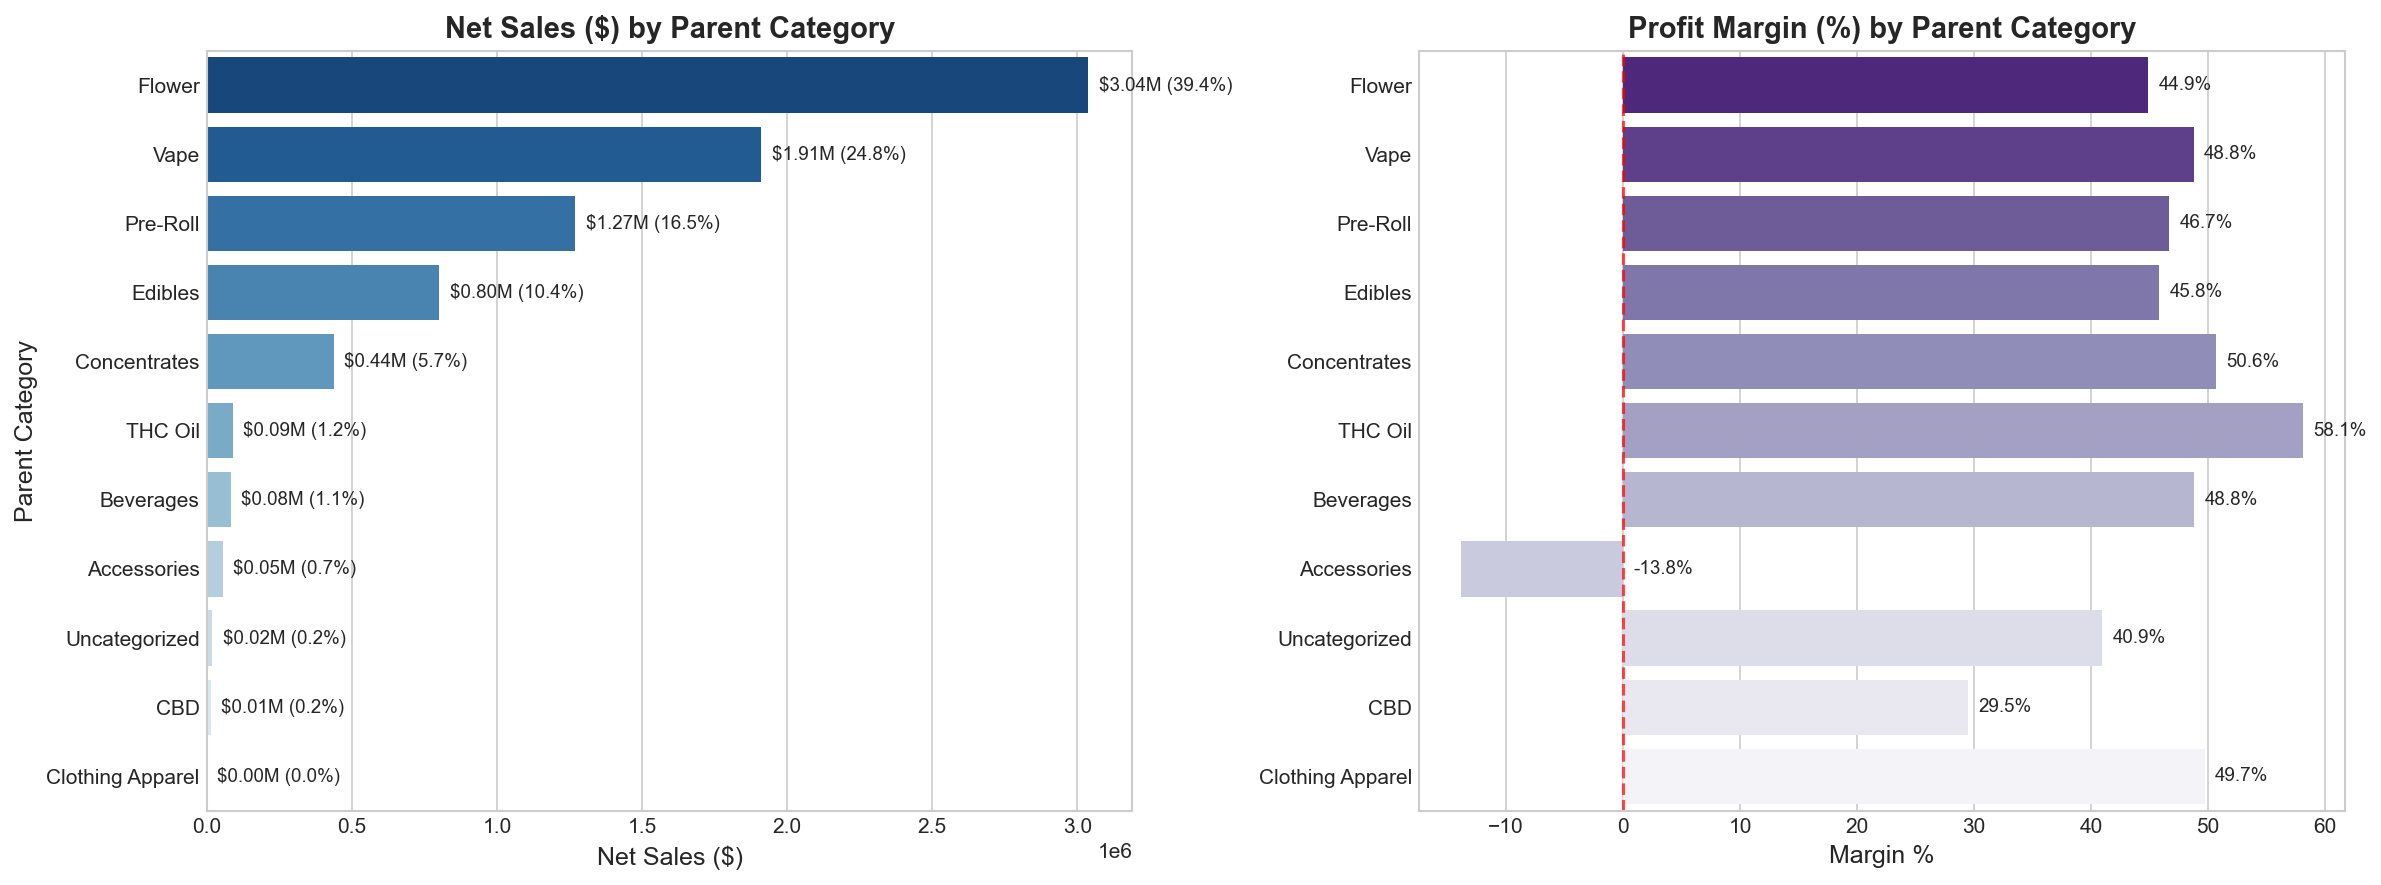

In [5]:
# Visual Supporting Charts for Q1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1A: Net Sales by Parent Category
sns.barplot(data=cat_perf, x='Net_Sales', y='PARENT CATEGORY', ax=ax1, palette='Blues_r')
ax1.set_title('Net Sales ($) by Parent Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Net Sales ($)', fontsize=12)
ax1.set_ylabel('Parent Category', fontsize=12)

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'${width/1e6:.2f}M ({width/df["NET SALES"].sum()*100:.1f}%)',
                (width, p.get_y() + p.get_height() / 2.),
                va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

# Chart 1B: Margin % by Parent Category
sns.barplot(data=cat_perf, x='Margin_%', y='PARENT CATEGORY', ax=ax2, palette='Purples_r')
ax2.axvline(0, color='red', linestyle='--', alpha=0.7)
ax2.set_title('Profit Margin (%) by Parent Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Margin %', fontsize=12)
ax2.set_ylabel('')

for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(f'{width:.1f}%',
                (max(width, 0), p.get_y() + p.get_height() / 2.),
                va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


## 5. Q2 — Concentration & Anomalies

### Pareto Revenue Concentration Analysis
We evaluate catalog and vendor concentration to determine the operational exposure of the business.


In [6]:
# Item Pareto Concentration
item_sales = df.groupby('ITEM NAME')['NET SALES'].sum().sort_values(ascending=False).reset_index()
item_sales['Cum_Sales'] = item_sales['NET SALES'].cumsum()
item_sales['Cum_Sales_%'] = (item_sales['Cum_Sales'] / item_sales['NET SALES'].sum()) * 100
item_sales['Item_Rank_%'] = ((item_sales.index + 1) / len(item_sales)) * 100

top_20_pct_items = item_sales[item_sales['Item_Rank_%'] <= 20.0]
top_80_sales_items = item_sales[item_sales['Cum_Sales_%'] <= 80.0]

print(f"Item Concentration:")
print(f" - Total Unique Items: {len(item_sales):,}")
print(f" - Top 20% of Items ({len(top_20_pct_items):,} SKUs) generate {top_20_pct_items['Cum_Sales_%'].iloc[-1]:.2f}% of Total Net Sales.")
print(f" - 80% of Total Revenue is generated by only {len(top_80_sales_items):,} SKUs ({len(top_80_sales_items)/len(item_sales)*100:.2f}% of the total catalog).")

# Vendor Pareto Concentration
vendor_sales = df.groupby('VENDOR')['NET SALES'].sum().sort_values(ascending=False).reset_index()
vendor_sales['Cum_Sales'] = vendor_sales['NET SALES'].cumsum()
vendor_sales['Cum_Sales_%'] = (vendor_sales['Cum_Sales'] / vendor_sales['NET SALES'].sum()) * 100
vendor_sales['Vendor_Rank_%'] = ((vendor_sales.index + 1) / len(vendor_sales)) * 100

top_20_pct_vendors = vendor_sales[vendor_sales['Vendor_Rank_%'] <= 20.0]
top_10_vendors_share = vendor_sales.head(10)['Cum_Sales_%'].iloc[-1]

print(f"\nVendor Concentration:")
print(f" - Total Vendors: {len(vendor_sales):,}")
print(f" - Top 20% of Vendors ({len(top_20_pct_vendors):,} vendors) generate {top_20_pct_vendors['Cum_Sales_%'].iloc[-1]:.2f}% of Total Net Sales.")
print(f" - Top 10 Vendors alone account for {top_10_vendors_share:.2f}% of total company revenue.")


Item Concentration:
 - Total Unique Items: 5,356
 - Top 20% of Items (1,071 SKUs) generate 59.40% of Total Net Sales.
 - 80% of Total Revenue is generated by only 2,055 SKUs (38.37% of the total catalog).

Vendor Concentration:
 - Total Vendors: 162
 - Top 20% of Vendors (32 vendors) generate 74.19% of Total Net Sales.
 - Top 10 Vendors alone account for 40.58% of total company revenue.


### Anomaly Detection: Negative Margin, Negative Sales, and Zero COGS Rows
The table below highlights critical data anomalies requiring operational audit.


In [7]:
# Flagged Anomalies
anomaly_neg_sales = df[df['NET SALES'] < 0][['ITEM NAME', 'LOCATION', 'PARENT CATEGORY', 'VENDOR', 'NET SALES', 'GROSS SALES', 'TOTAL COGS', 'QUANTITY SOLD']]
anomaly_neg_margin = df[(df['MARGIN_DOLLARS'] < 0) & (df['NET SALES'] > 0)].sort_values(by='MARGIN_DOLLARS').head(10)[['ITEM NAME', 'LOCATION', 'PARENT CATEGORY', 'VENDOR', 'NET SALES', 'TOTAL COGS', 'MARGIN_DOLLARS', 'MARGIN_PCT']]

print("1. Negative Net Sales Records (Customer Returns / Adjustments):")
display(anomaly_neg_sales)

print("\n2. Top 10 Negative Margin Rows (Significant Loss-Making Records):")
display(anomaly_neg_margin.style.format({
    'NET SALES': '${:,.2f}',
    'TOTAL COGS': '${:,.2f}',
    'MARGIN_DOLLARS': '${:,.2f}',
    'MARGIN_PCT': '{:.2%}'
}))


1. Negative Net Sales Records (Customer Returns / Adjustments):


,ITEM NAME,LOCATION,PARENT CATEGORY,VENDOR,NET SALES,GROSS SALES,TOTAL COGS,QUANTITY SOLD
217,Series-A-0184,B,Accessories,Vendor-001,-174.33,-175.00,-175.0,-1
7097,Series-E-0295,B,Vape,Vendor-079,-30.93,-30.99,-16.0,-1
8355,Series-F-0059,A,Vape,Vendor-058,-1.03,0.00,0.0,0



2. Top 10 Negative Margin Rows (Significant Loss-Making Records):


,ITEM NAME,LOCATION,PARENT CATEGORY,VENDOR,NET SALES,TOTAL COGS,MARGIN_DOLLARS,MARGIN_PCT
225,Series-A-0189,B,Accessories,Vendor-001,$252.51,"$10,250.00","$-9,997.49",-3959.25%
223,Series-A-0189,A,Accessories,Vendor-001,$129.79,"$7,362.50","$-7,232.71",-5572.63%
6456,Series-D-0908,B,Pre-Roll,Vendor-111,"$1,304.74","$2,438.00","$-1,133.26",-86.86%
3105,Series-B-0859,B,Flower,Vendor-072,"$1,467.21","$2,136.00",$-668.79,-45.58%
6931,Series-E-0196,B,Pre-Roll,Vendor-137,$454.45,"$1,056.00",$-601.55,-132.37%
2540,Series-B-0527,A,Flower,Vendor-089,$632.52,"$1,088.00",$-455.48,-72.01%
3106,Series-B-0860,B,Flower,Vendor-072,"$1,005.42","$1,440.00",$-434.58,-43.22%
2539,Series-B-0527,B,Flower,Vendor-089,$858.27,"$1,280.00",$-421.73,-49.14%
7034,Series-E-0258,B,Uncategorized,Vendor-001,$0.12,$360.00,$-359.88,-299900.00%
42,Series-A-0041,B,Accessories,Vendor-001,$342.54,$640.00,$-297.46,-86.84%


## 6. Q3 — Strategic Merchandising Actions

### Action Framework: Investigate / Protect / Promote / Reprice / Reduce / Discontinue
Using the velocity and dead-stock tiering from Section 3 as direct evidence, we categorize catalog SKUs into specific merchandising actions, naming explicit items and categories.

*Note that **Investigate** and **Discontinue** are not mutually exclusive — an item can be both a Dead Stock discontinue candidate and a flagged accounting anomaly (e.g. `Series-A-0189`), so action-category SKU counts should not be summed as if they were distinct buckets.*

1. **PROTECT (Fast Movers + High Margin $\ge 45\%$)**: High-volume, highly profitable cash cows. Must maintain continuous in-stock status and prioritize vendor allocation.
2. **REPRICE / RENEGOTIATE (Fast Movers + Lower Margin $< 45\%$)**: High unit velocity but lower margin. Renegotiate wholesale supplier cost or implement targeted retail price adjustments. Every Fast Mover is fully covered by either Protect ($\ge 45\%$) or Reprice ($< 45\%$).
3. **PROMOTE (Medium Movers + High Margin $\ge 50\%$)**: Highly profitable Assortment drivers with room for unit volume expansion through prominent display and staff recommendations.
4. **REDUCE / RATIONALIZE (Slow Movers, Percentile $\le 0.30$)**: Low turnover SKUs that fragment inventory capital and shelf presence.
5. **DISCONTINUE (Dead Stock, Percentile $\le 0.10$ or Qty $\le 0$)**: Stagnant inventory selling $\le 1-2$ units in 6 months; initiate final markdown liquidation.
6. **INVESTIGATE (Data & Accounting Anomalies)**: Immediate review of severe loss records and zero-COGS entries.


In [8]:
# Filter items for each action
# Ensure complete coverage for Fast Movers: Protect (>=45%) and Reprice (<45%)
action_protect = df[(df['TIER'] == 'Fast Mover') & (df['MARGIN_PCT'] >= 0.45)].sort_values(by='NET SALES', ascending=False)
action_reprice = df[(df['TIER'] == 'Fast Mover') & (df['MARGIN_PCT'] < 0.45)].sort_values(by='NET SALES', ascending=False)
action_promote = df[(df['TIER'] == 'Medium Mover') & (df['MARGIN_PCT'] >= 0.50)].sort_values(by='NET SALES', ascending=False)
action_reduce = df[df['TIER'] == 'Slow Mover'].sort_values(by='NET SALES', ascending=True)
action_discontinue = df[df['TIER'] == 'Dead Stock'].sort_values(by='TOTAL COGS', ascending=False)
action_investigate = df[(df['MARGIN_DOLLARS'] < 0) | (df['NET SALES'] <= 0) | (df['TOTAL COGS'] == 0)].sort_values(by='MARGIN_DOLLARS')

print(f"1. PROTECT Assortment: {len(action_protect):,} SKUs (Top Examples)")
display(action_protect[['ITEM NAME', 'PARENT CATEGORY', 'LOCATION', 'VENDOR', 'NET SALES', 'QUANTITY SOLD', 'MARGIN_PCT']].head(4).style.format({'NET SALES': '${:,.2f}', 'MARGIN_PCT': '{:.2%}'}))

print(f"\n2. REPRICE / RENEGOTIATE: {len(action_reprice):,} SKUs (Top Examples)")
display(action_reprice[['ITEM NAME', 'PARENT CATEGORY', 'LOCATION', 'VENDOR', 'NET SALES', 'QUANTITY SOLD', 'MARGIN_PCT']].head(4).style.format({'NET SALES': '${:,.2f}', 'MARGIN_PCT': '{:.2%}'}))

print(f"\n3. PROMOTE / FEATURE: {len(action_promote):,} SKUs (Top Examples)")
display(action_promote[['ITEM NAME', 'PARENT CATEGORY', 'LOCATION', 'VENDOR', 'NET SALES', 'QUANTITY SOLD', 'MARGIN_PCT']].head(4).style.format({'NET SALES': '${:,.2f}', 'MARGIN_PCT': '{:.2%}'}))

print(f"\n4. REDUCE / RATIONALIZE: {len(action_reduce):,} SKUs (Bottom Movement Examples)")
display(action_reduce[['ITEM NAME', 'PARENT CATEGORY', 'LOCATION', 'VENDOR', 'NET SALES', 'QUANTITY SOLD', 'MARGIN_PCT']].head(4).style.format({'NET SALES': '${:,.2f}', 'MARGIN_PCT': '{:.2%}'}))

print(f"\n5. DISCONTINUE (Dead Stock): {len(action_discontinue):,} SKUs (Top COGS Capital at Risk)")
display(action_discontinue[['ITEM NAME', 'PARENT CATEGORY', 'LOCATION', 'VENDOR', 'NET SALES', 'TOTAL COGS', 'QUANTITY SOLD']].head(4).style.format({'NET SALES': '${:,.2f}', 'TOTAL COGS': '${:,.2f}'}))

print(f"\n6. INVESTIGATE (Anomalous SKUs): {len(action_investigate):,} SKUs (Severe Margin Distortions)")
display(action_investigate[['ITEM NAME', 'PARENT CATEGORY', 'LOCATION', 'VENDOR', 'NET SALES', 'TOTAL COGS', 'MARGIN_DOLLARS']].head(4).style.format({'NET SALES': '${:,.2f}', 'TOTAL COGS': '${:,.2f}', 'MARGIN_DOLLARS': '${:,.2f}'}))


1. PROTECT Assortment: 1,092 SKUs (Top Examples)


,ITEM NAME,PARENT CATEGORY,LOCATION,VENDOR,NET SALES,QUANTITY SOLD,MARGIN_PCT
4623,Series-C-0832,Flower,B,Vendor-145,"$14,662.94",127,45.87%
4204,Series-C-0565,Flower,B,Vendor-089,"$12,440.76",50,48.00%
6967,Series-E-0218,THC Oil,B,Vendor-005,"$11,945.43",214,46.26%
4232,Series-C-0584,Flower,B,Vendor-089,"$11,772.82",49,46.31%



2. REPRICE / RENEGOTIATE: 1,105 SKUs (Top Examples)


,ITEM NAME,PARENT CATEGORY,LOCATION,VENDOR,NET SALES,QUANTITY SOLD,MARGIN_PCT
4137,Series-C-0522,Flower,B,Vendor-100,"$31,602.49",407,42.38%
4141,Series-C-0523,Flower,B,Vendor-100,"$24,847.35",319,43.77%
4269,Series-C-0606,Flower,B,Vendor-089,"$18,483.59",77,39.17%
4196,Series-C-0560,Flower,B,Vendor-089,"$18,141.39",76,38.00%



3. PROMOTE / FEATURE: 535 SKUs (Top Examples)


...

,ITEM NAME,PARENT CATEGORY,LOCATION,VENDOR,NET SALES,QUANTITY SOLD,MARGIN_PCT
4333,Series-C-0645,Flower,C,Vendor-087,$0.03,3,-799900.00%
187,Series-A-0157,Accessories,C,Vendor-001,$5.91,3,68.53%
4,Series-A-0005,Accessories,A,Vendor-001,$7.41,2,64.91%
192,Series-A-0161,Accessories,B,Vendor-001,$9.77,3,-207.06%



5. DISCONTINUE (Dead Stock): 1,230 SKUs (Top COGS Capital at Risk)


,ITEM NAME,PARENT CATEGORY,LOCATION,VENDOR,NET SALES,TOTAL COGS,QUANTITY SOLD
219,Series-A-0186,Accessories,B,Vendor-001,$452.68,$479.99,1
126,Series-A-0108,Accessories,A,Vendor-001,$359.76,$250.00,1
4270,Series-C-0606,Flower,A,Vendor-089,$472.00,$245.00,2
176,Series-A-0149,Accessories,B,Vendor-001,$205.81,$229.00,1



6. INVESTIGATE (Anomalous SKUs): 190 SKUs (Severe Margin Distortions)


,ITEM NAME,PARENT CATEGORY,LOCATION,VENDOR,NET SALES,TOTAL COGS,MARGIN_DOLLARS
225,Series-A-0189,Accessories,B,Vendor-001,$252.51,"$10,250.00","$-9,997.49"
223,Series-A-0189,Accessories,A,Vendor-001,$129.79,"$7,362.50","$-7,232.71"
6456,Series-D-0908,Pre-Roll,B,Vendor-111,"$1,304.74","$2,438.00","$-1,133.26"
3105,Series-B-0859,Flower,B,Vendor-072,"$1,467.21","$2,136.00",$-668.79


## 7. Q4 — What's Missing for Replenishment Decisions

### Critical Operational Data Gaps & Solutions
While the 6-month sales snapshot provides strategic assortment visibility, automated and sound inventory replenishment cannot be performed safely with this file alone. Below is the structured plain-language breakdown of missing operational parameters:

| Missing Signal / Operational Variable | Business Impact of Gap | Data Required to Close Gap |
| :--- | :--- | :--- |
| **1. Transaction Date / Timestamps** | Cannot calculate velocity recency, sales run-rate decay, or days-since-last-sale. A product that sold 20 units in Month 1 and 0 units in Months 2–6 looks identical to a steady seller. | POS transaction log containing timestamp, transaction ID, and unit quantity per receipt. |
| **2. Inventory-on-Hand (Current Stock)** | Cannot determine whether 0-sale SKUs reflect unfulfilled stockouts (phantom inventory/lost sales) or true zero customer demand (dead stock). | Live ERP/WMS inventory snapshot with on-hand, in-transit, and safety stock units. |
| **3. Supplier Lead Times & Order Cycles** | Cannot compute accurate Reorder Points (ROP) or Safety Stock buffers. High lead-time items (e.g. 4 weeks) risk frequent stockouts. | Vendor catalog master data including vendor lead time (days), order minimums (MOQs), and delivery frequency. |
| **4. Seasonality & Promotional Calendars** | Cannot distinguish baseline organic demand from marketing lifts, holiday spikes, or localized events. | Historical multi-year monthly sales data, markdown tracking, and planned marketing campaign calendars. |
| **5. Shrinkage, Spoilage & Damaged Goods** | Real-world inventory balances may diverge from theoretical sales balances due to theft, expiry, or breakage. | Inventory audit cycle counts, waste logs, and return reason codes. |


## 8. Q5 — Next 30 Days Action Plan

### Concrete Operational Actions Citing Specific Dataset Numbers

1. **Audit & Correct Series-A-0189 COGS Accounting Distortion (Section 2 & 5)**:
   - *Action*: Conduct an immediate audit of item `Series-A-0189` in Location B ($10,250.00 COGS vs $252.51 sales) and Location A ($7,362.50 COGS vs $129.79 sales). This single item accounts for $-\$17,230.20$ in margin deficit, artificially depressing the entire Accessories category into a negative margin ($-13.83\%$).
2. **Execute Clearance Markdown on 1,230 Dead-Stock SKUs (Section 3)**:
   - *Action*: Implement an immediate 30-day promotional markdown on the 1,230 Dead Stock SKUs (selling $\le 1-2$ units) to recover trapped working capital ($\$40,413.52$ COGS exposure) and free up shelf space.
3. **Renegotiate Cost or Reprice Low-Margin Fast Movers (Section 6)**:
   - *Action*: Address volume items generating $<45\%$ margin (e.g., `Series-C-0606` at 39.2% margin on $18.48k sales; `Series-C-0560` at 38.0% margin on $18.14k sales from `Vendor-089`). Target a +3–5% gross margin expansion through wholesale volume tiering or a 2–3% retail price adjustment.
4. **Assortment Expansion of Top Core Cash Cows (Section 6)**:
   - *Action*: Establish guaranteed replenishment priority for top Fast Mover + High Margin items (e.g., `Series-C-0832` in Location B generating $14,662.94 net sales at 45.9% margin; `Series-C-0565` generating $12,440.76 net sales at 48.0% margin).
5. **Vendor Rationalization Review (Section 4 & 5)**:
   - *Action*: The top 10 vendors account for 40.58% of revenue ($3.13M). Establish quarterly business reviews with top partners (`Vendor-089`, `Vendor-023`, `Vendor-046`, `Vendor-038`) to negotiate joint advertising and co-op allowances.
6. **Location C Assortment Rebalancing (Section 4)**:
   - *Action*: Location C generated only $60,087.38 (0.78% of sales) across 670 SKUs (averaging under $90 per SKU). Trim Location C's active catalog by 50% to focus purely on top 150 company-wide Fast Movers.
7. **Integrate Real-Time POS & On-Hand Inventory Feeds (Section 7)**:
   - *Action*: Commission the engineering team to pipe timestamped POS receipt logs and daily store-level on-hand inventory balances into the data warehouse to unlock dynamic Days-of-Inventory (DOI) tracking.


## 9. Visual Evidence & Chart Exports
The 5 key analytical charts generated and exported for executive reporting:
1. `visuals/chart1_revenue_margin_by_category.png` — Category Net Sales vs Profit Margin %
2. `visuals/chart2_pareto_revenue_concentration.png` — Pareto Lorenz Curve (SKUs vs Vendors)
3. `visuals/chart3_velocity_tier_distribution.png` — Velocity Tier Distribution (SKU Share vs Sales Share)
4. `visuals/chart4_location_store_performance.png` — Location Contribution & Margin Health
5. `visuals/chart5_margin_vs_velocity_quadrant.png` — Merchandising Strategy Action Matrix


Visual Evidence Deliverable: visuals/chart1_revenue_margin_by_category.png


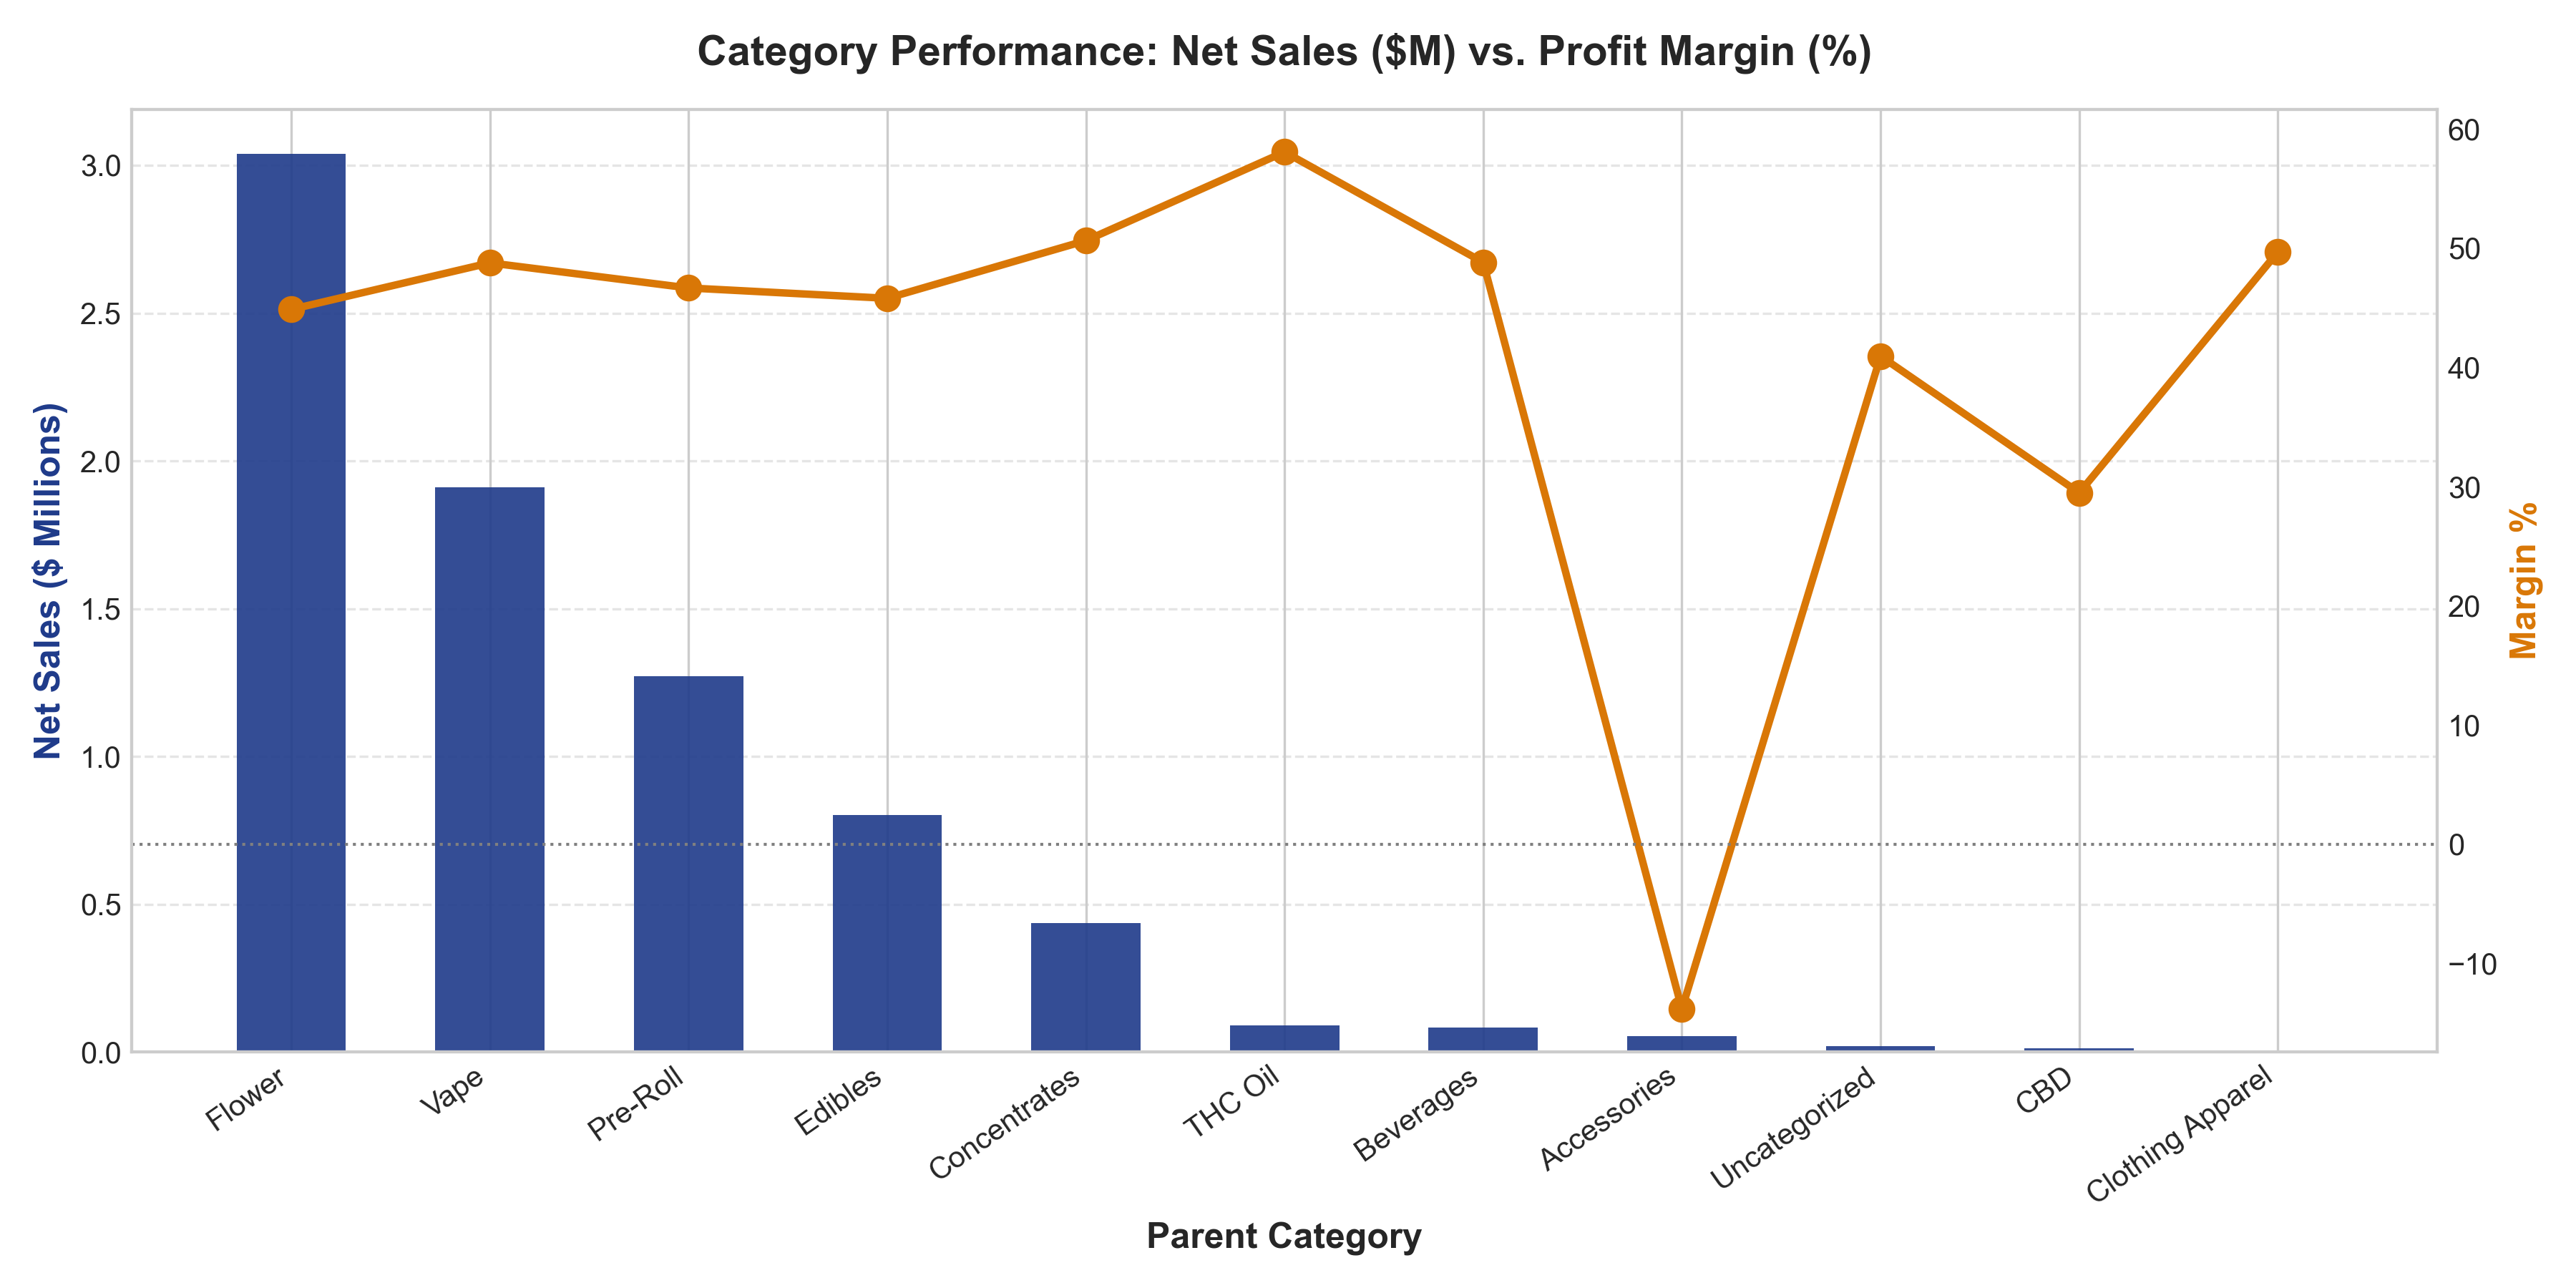

Visual Evidence Deliverable: visuals/chart2_pareto_revenue_concentration.png


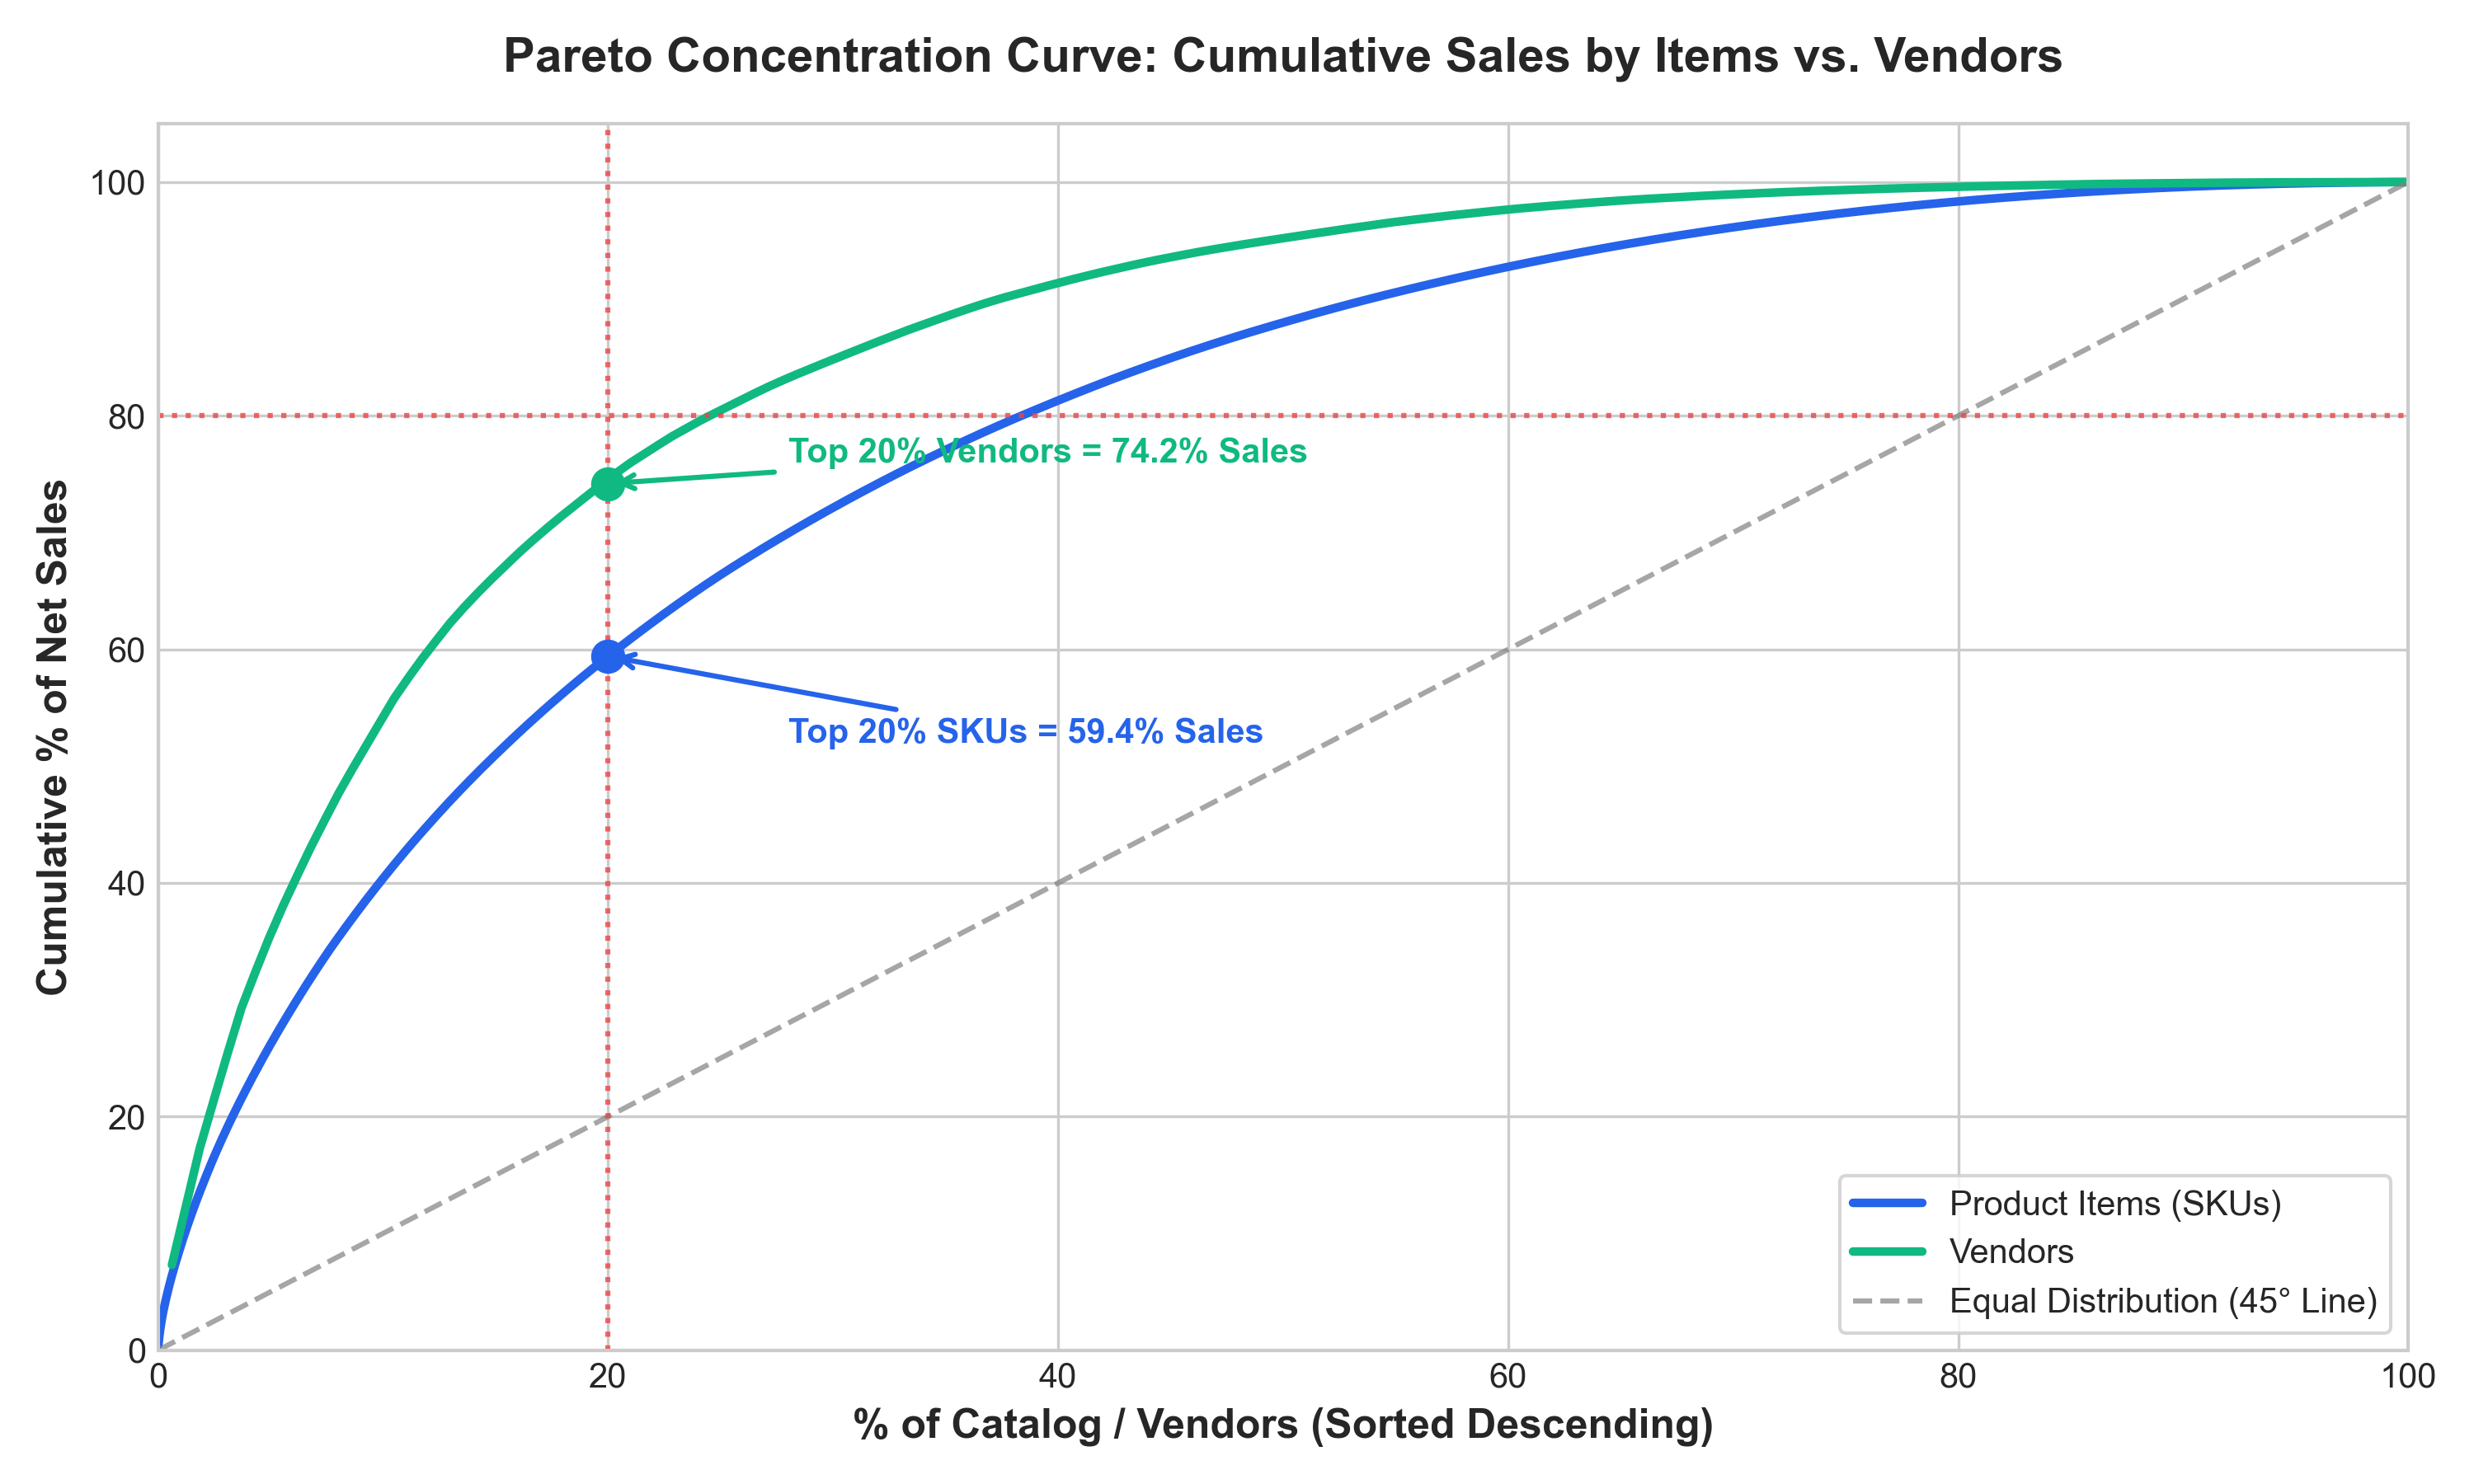

Visual Evidence Deliverable: visuals/chart3_velocity_tier_distribution.png


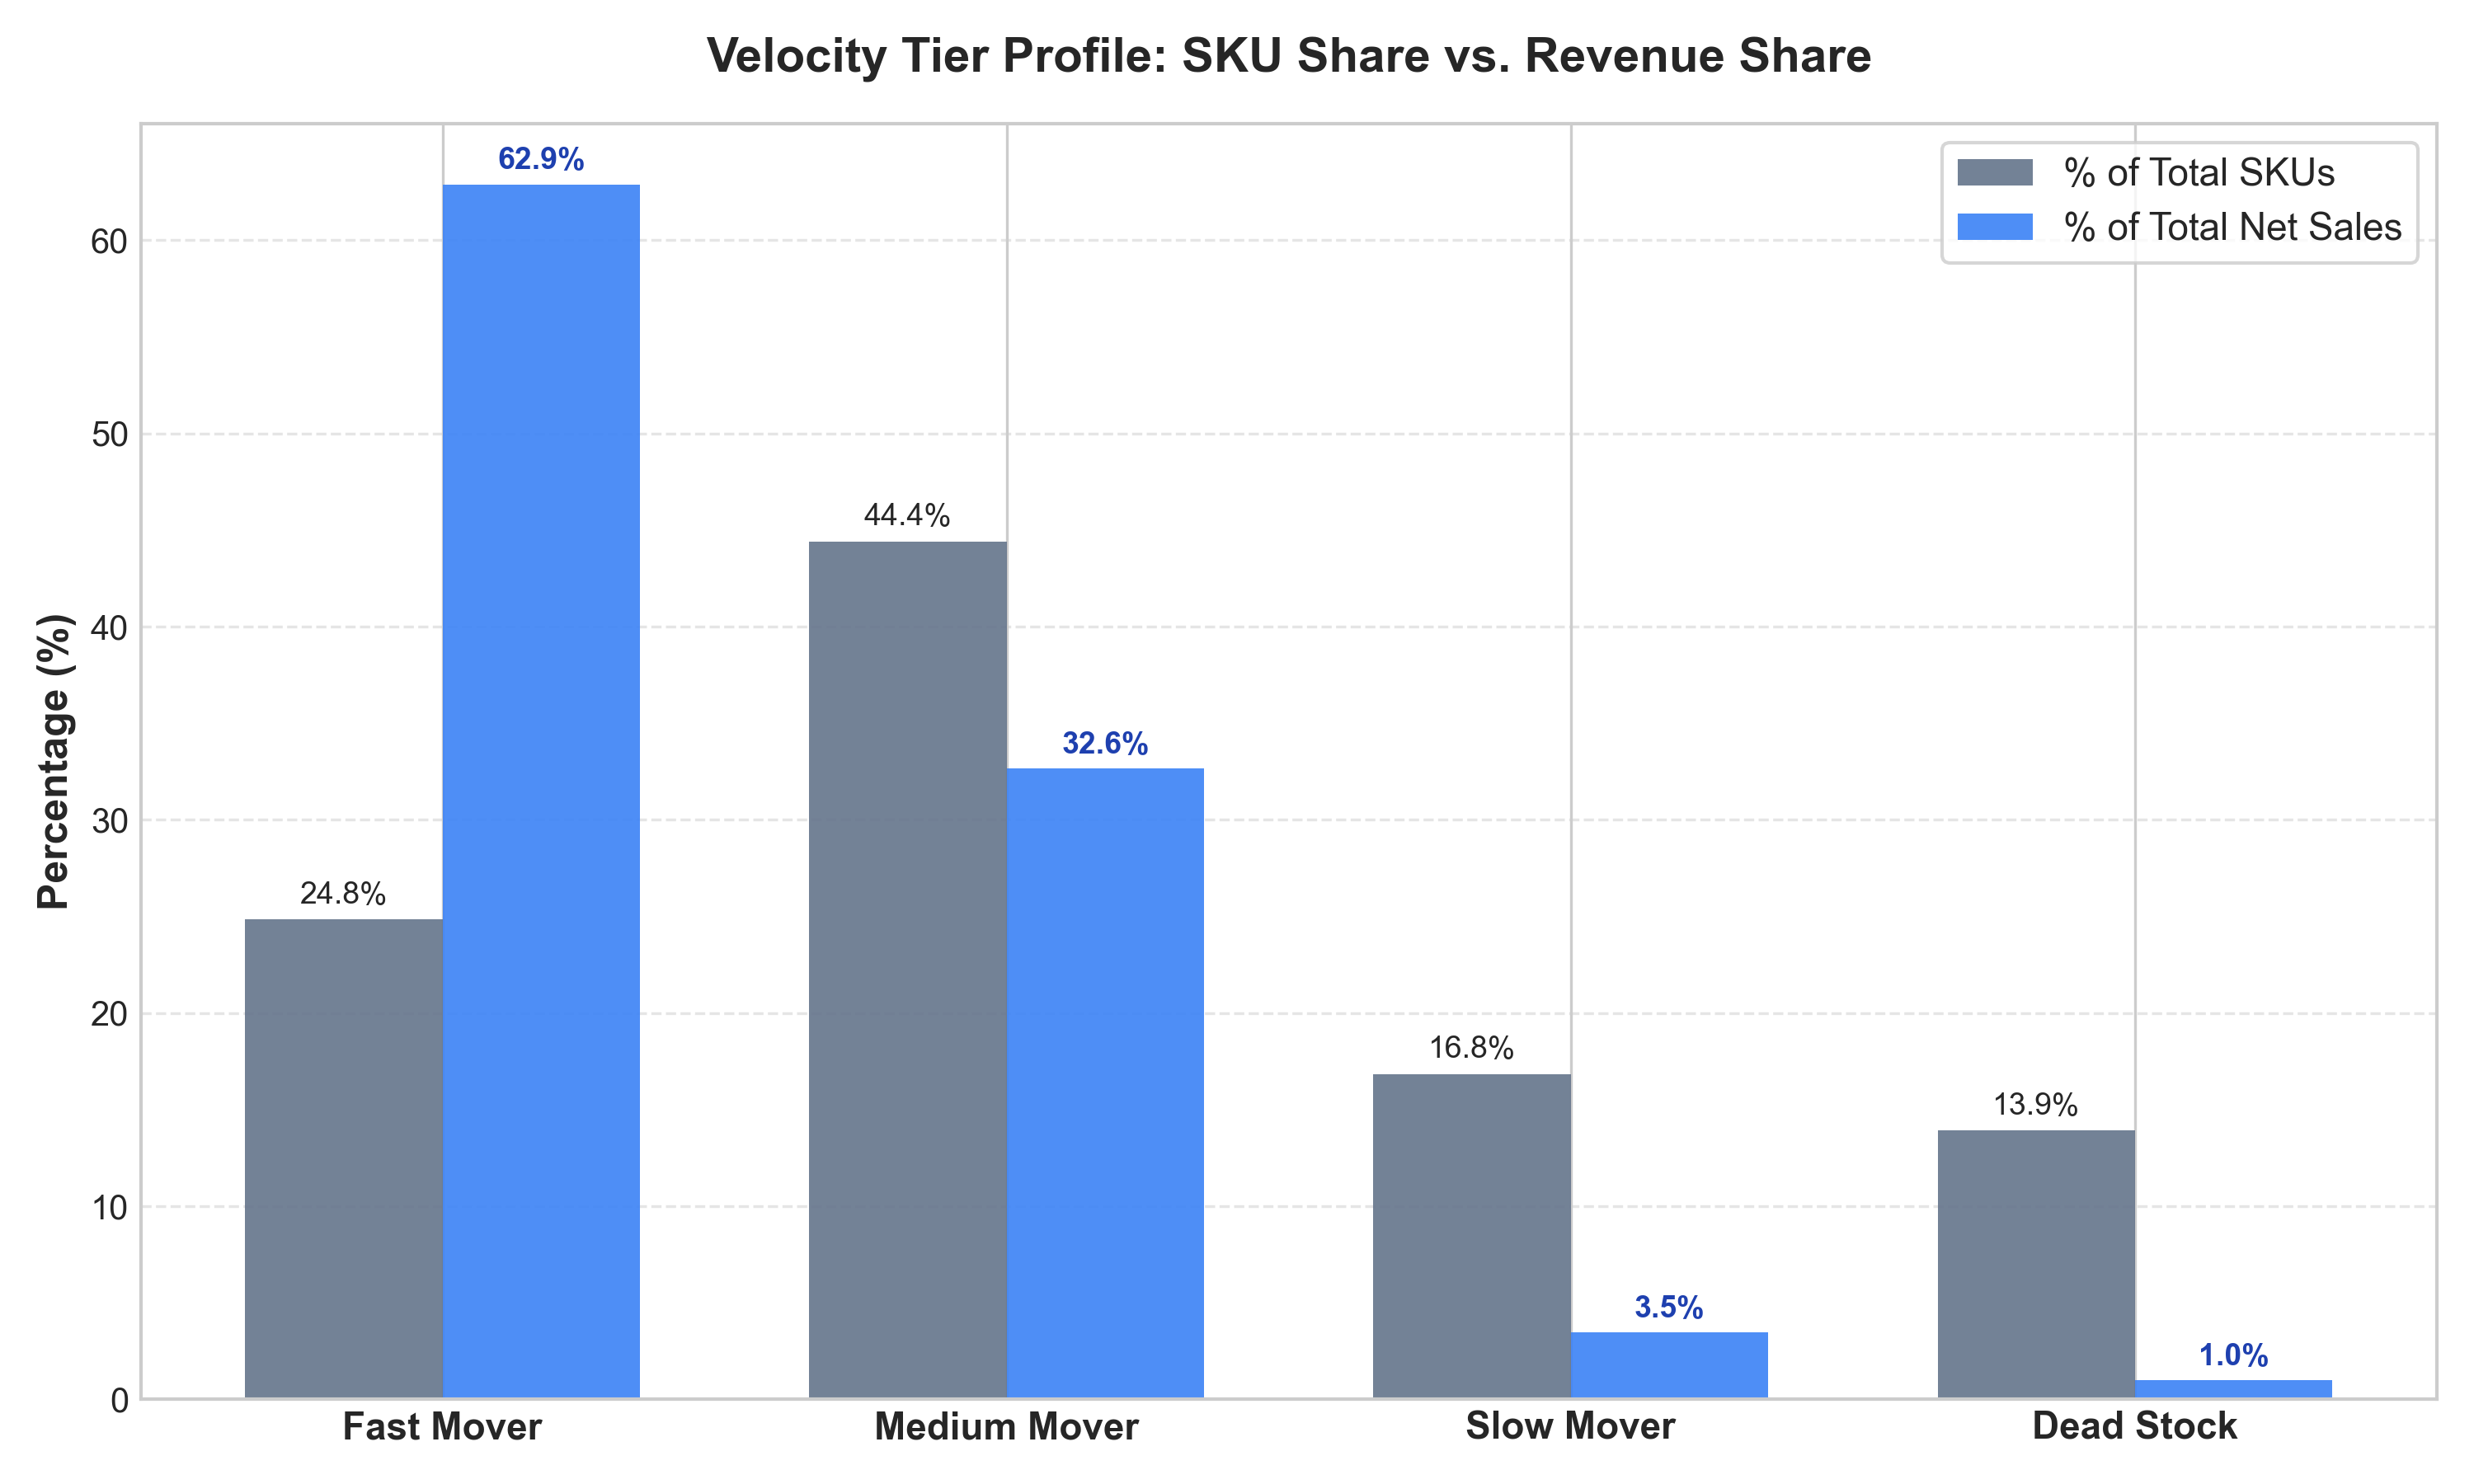

Visual Evidence Deliverable: visuals/chart4_location_store_performance.png


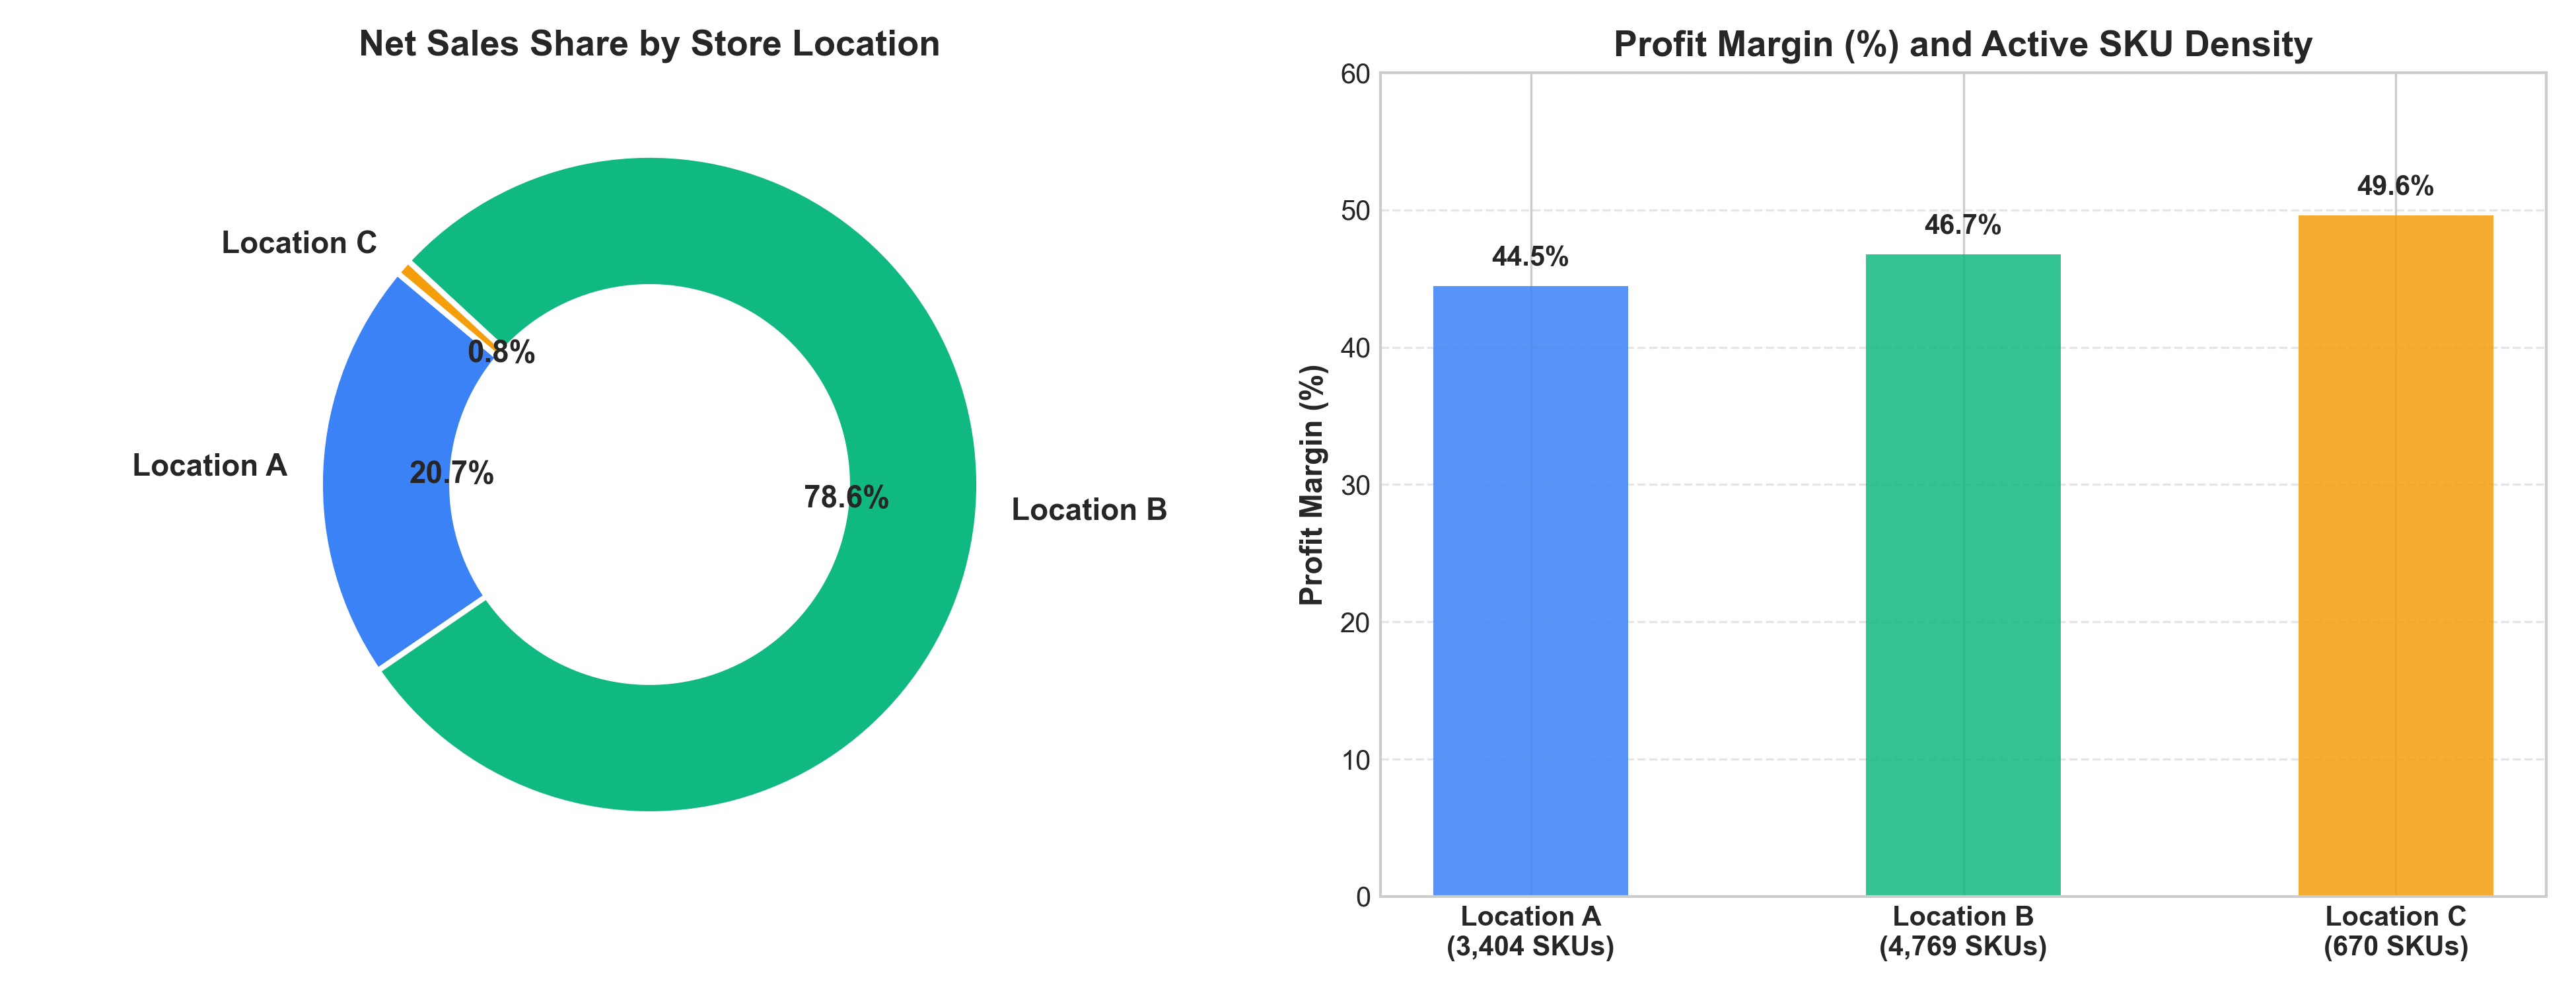

Visual Evidence Deliverable: visuals/chart5_margin_vs_velocity_quadrant.png


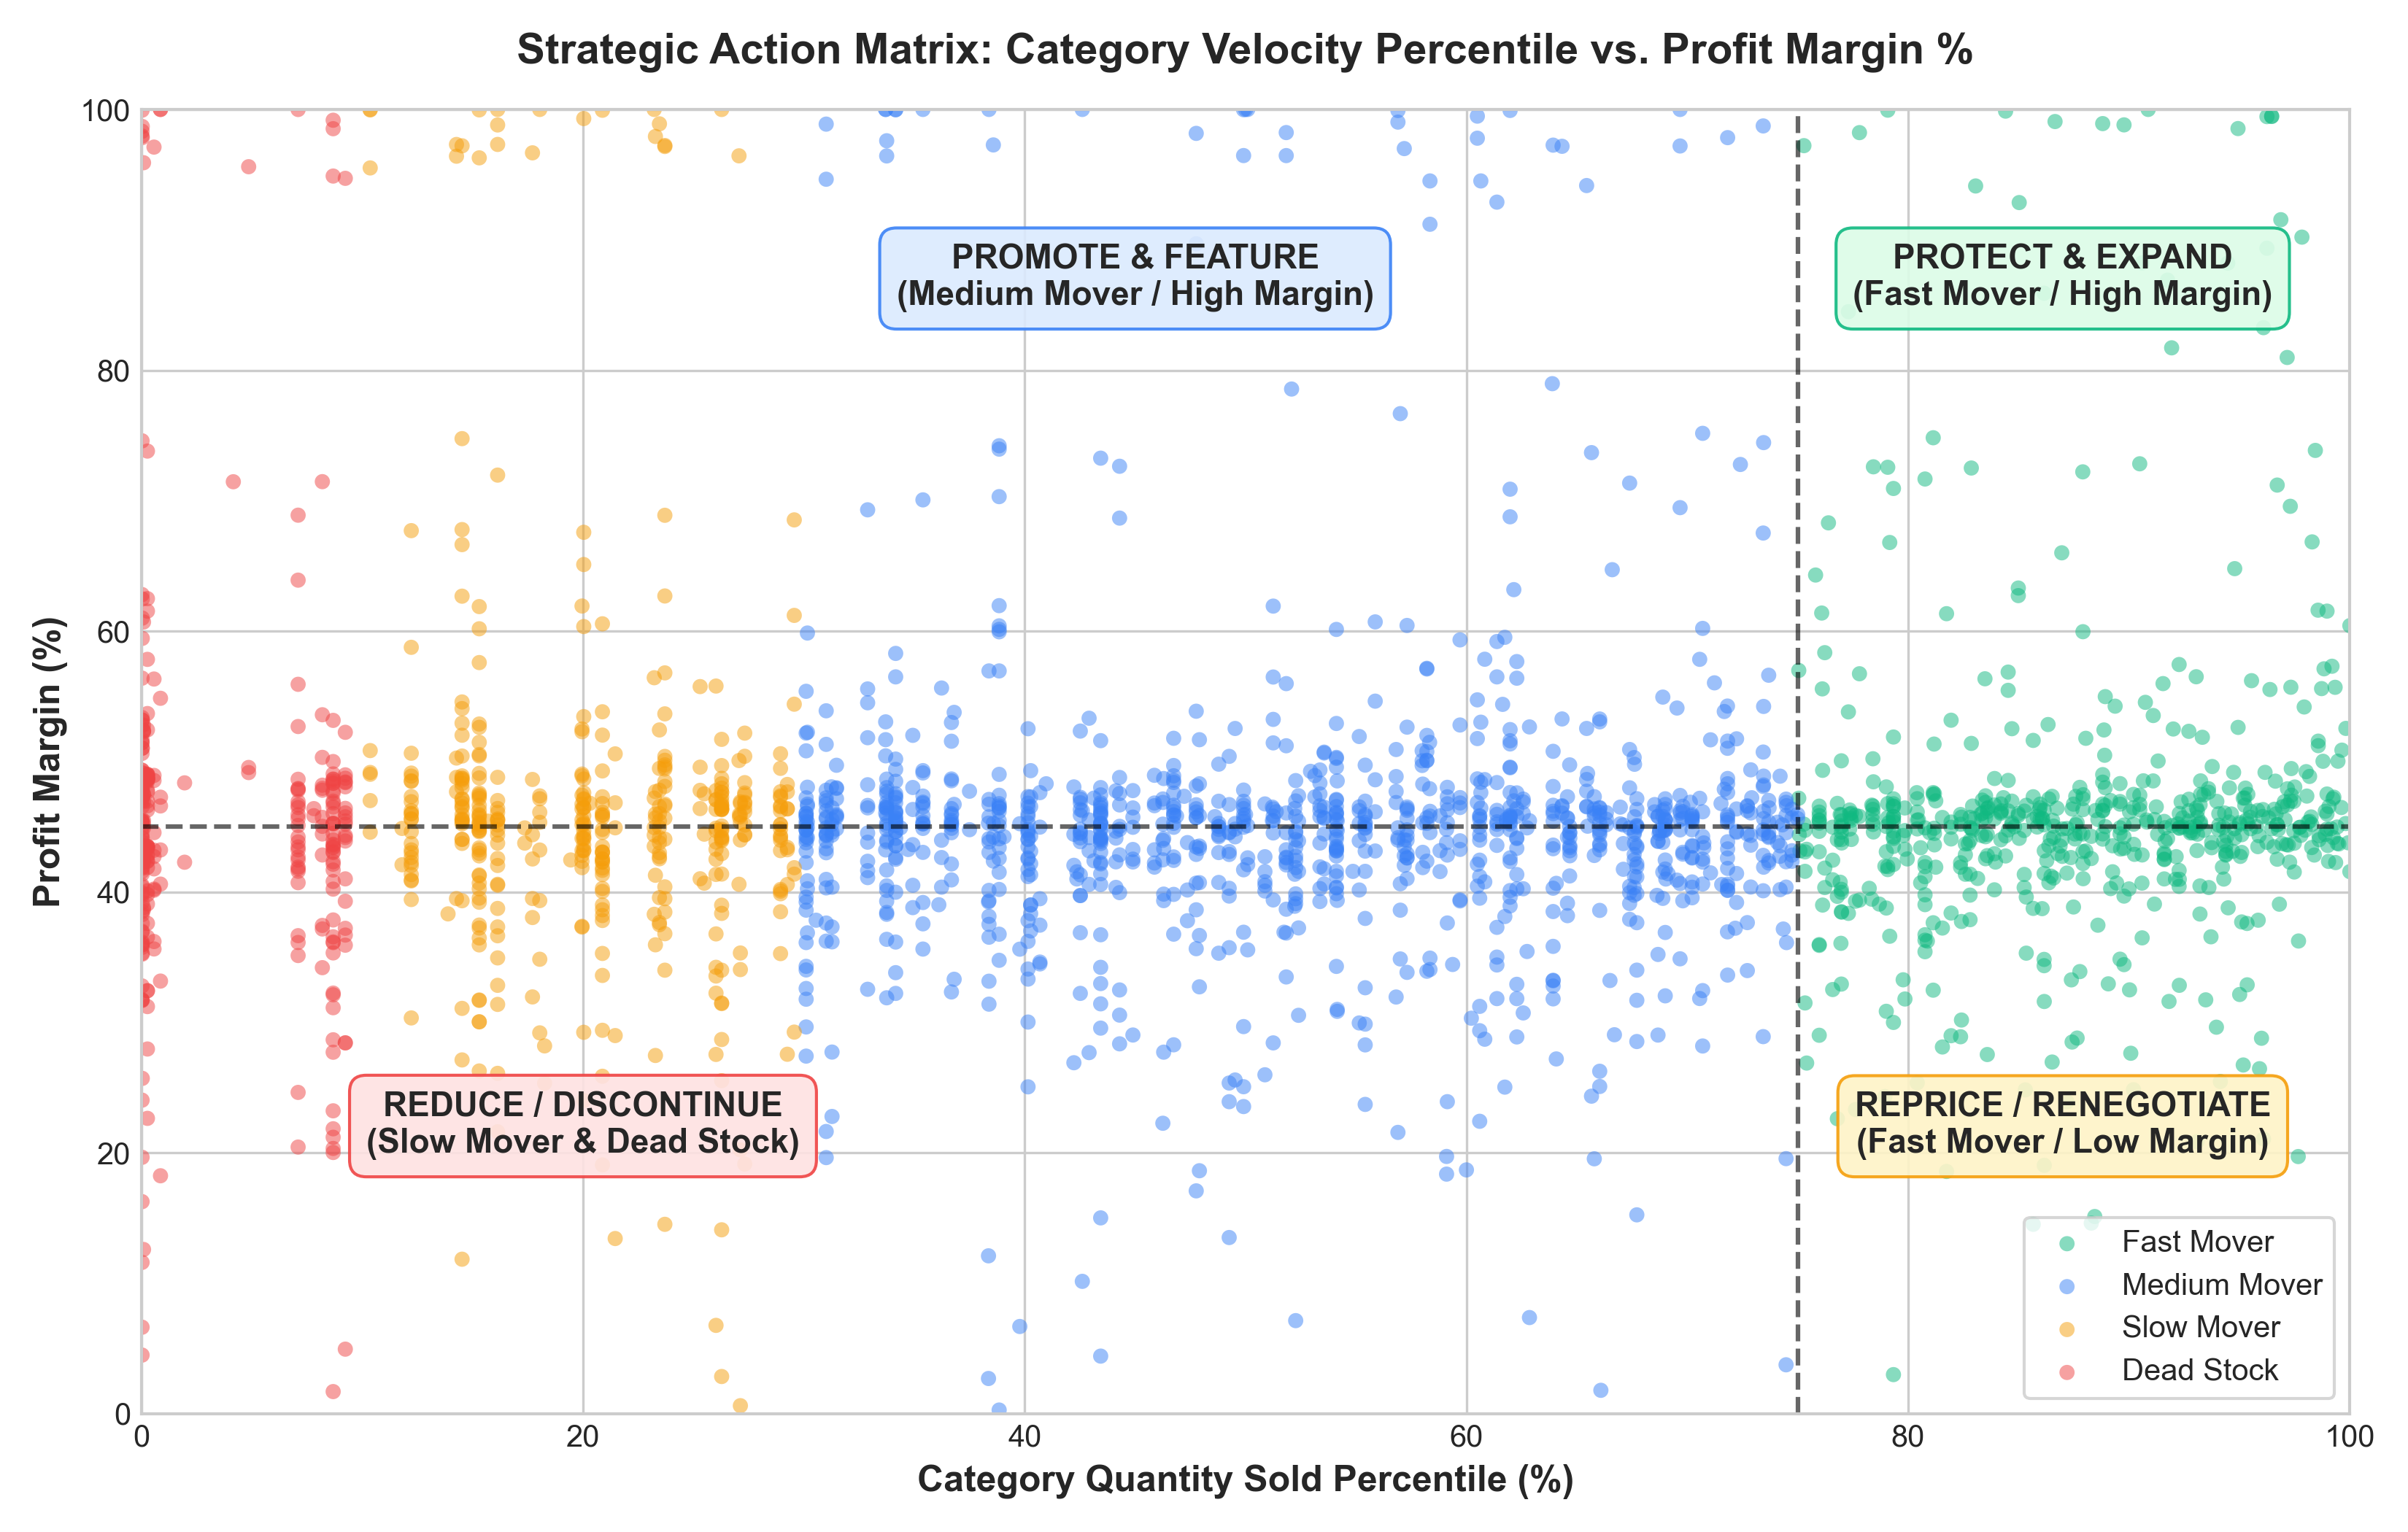

In [9]:
# Display Exported Visual Charts in Notebook
from IPython.display import Image, display

chart_paths = [
    'visuals/chart1_revenue_margin_by_category.png',
    'visuals/chart2_pareto_revenue_concentration.png',
    'visuals/chart3_velocity_tier_distribution.png',
    'visuals/chart4_location_store_performance.png',
    'visuals/chart5_margin_vs_velocity_quadrant.png'
]

for p in chart_paths:
    if os.path.exists(p):
        print(f"Visual Evidence Deliverable: {p}")
        display(Image(filename=p, width=800))


## 10. AI Work Log

### Transparency, Prompt Tracking, and Manual Verification Log
- **AI Tooling Utilized**: Antigravity AI Engineering Suite & Gemini 3.7.
- **Initial Prompts Used**:
  - *"Build an end-to-end retail analytics deliverable from Product_Sales_Analysis.xlsx establishing single source of truth without data fabrication."*
  - *"Standardize whitespace, compute category-relative velocity percentiles, audit negative sales and margin outliers, and output clean item_velocity.csv."*
  - *"Formulate 5 core business question answers (Q1-Q5), export PNG visuals, generate executive summary (DOCX/PDF), and create an interactive web dashboard."*
- **Revisions & Adjustments Made**:
  1. *Category Whitespace Resolution*: Identified 11 true parent categories after stripping trailing whitespace (resolving `'Flower '` and `'Flower'` duplicates).
  2. *Margin Recalculation*: Discovered severe division distortion where penny sales produced $-799,900\%$ margins; instituted explicit mathematical recalculation rule ($(\text{Net Sales} - \text{COGS})/\text{Net Sales}$ where Net Sales > 0).
  3. *Dead Stock Root Cause Analysis*: Isolated item `Series-A-0189` incurring over $-\$17.2\text{k}$ in COGS overstatement across Locations A and B, which single-handedly turned the entire Accessories department margin negative.
  4. *Action Matrix Boundary Alignment*: Aligned Reprice ($<45\%$) and Protect ($\ge 45\%$) boundary thresholds to ensure full, non-overlapping coverage across all Fast Movers.
- **Independent Manual Verifications Conducted**:
  - Total Net Sales verified against raw spreadsheet ($7,712,364.96).
  - Total COGS verified against raw spreadsheet ($4,141,731.68).
  - Total Quantity Sold verified against raw spreadsheet (268,741 units).
  - Velocity tier count verified (Fast Mover: 2,197, Medium Mover: 3,927, Slow Mover: 1,489, Dead Stock: 1,230; total: 8,843).
